# Problem-Attention Model Comparison

Replaces the hand-weighted heuristic in `picker.py` with a model trained on real attempt outcomes.

**Target:** `needs_attention = 1` if an attempt's result was `failed` or `partial`, `0` if `solved`.

**Models compared:** Logistic Regression → Decision Tree → XGBoost (gradient boosting), evaluated on a
**time-based** train/test split (train on earlier attempts, test on later ones) since this is a
sequential problem, not i.i.d. data.

**v4 update:** adds a manually-curated `pattern` field (Two Pointers, Sliding Window, Dynamic
Programming, etc. — 21 categories, all 198 problems now tagged) as a single categorical feature.
Unlike the earlier `topic_tags` experiment (LeetCode's own multi-label tags, which hurt AUC), this
is single-select — every problem has exactly one pattern — so it's denser signal per column. Still
worth watching for the same dimensionality risk: 21 categories means ~20 one-hot columns on top of
the existing ~10 features, and several patterns have very few problems (Bit Manipulation: 2,
Tries: 2), so their coefficients will be noisy.

**v5 update:** `SQL` is now excluded from training and scoring entirely (see `EXCLUDED_PATTERNS`
below) — every SQL attempt in this data had the same outcome, which caused
`statsmodels`/logistic regression to report a quasi-separated, effectively-infinite coefficient
for it. The 12 SQL problems stay tracked in the database; they just don't participate in the
model. This mirrors the same exclusion now applied in `picker.py`.


In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

## 1. Load data

In [2]:
conn = sqlite3.connect('../leetcode_tracker.db')
attempts = pd.read_sql_query("""
    SELECT pa.attempt_id, pa.problem_id, pa.attempt_date, pa.bucket, pa.result, pa.solve_time,
           p.difficulty, p.created_date, p.pattern
    FROM problem_attempts pa
    JOIN problems p ON pa.problem_id = p.problem_id
""", conn)
conn.close()

print(f"{len(attempts)} attempts across {attempts['problem_id'].nunique()} problems")
print(f"Missing pattern: {attempts['pattern'].isna().sum()}")
print(attempts['pattern'].value_counts())

# SQL caused quasi-separation below (every SQL attempt had the same outcome,
# producing an unreliable, unbounded coefficient) — excluded from training and
# scoring, same as picker.py. The problems stay in the database untouched.
EXCLUDED_PATTERNS = ['SQL']
attempts = attempts[~attempts['pattern'].isin(EXCLUDED_PATTERNS)].reset_index(drop=True)
print(f"\nAfter excluding {EXCLUDED_PATTERNS}: {len(attempts)} attempts across {attempts['problem_id'].nunique()} problems")
attempts.head()

275 attempts across 198 problems
Missing pattern: 0
pattern
Trees                  43
Arrays & Hashing       33
Linked List            31
Dynamic Programming    27
Two Pointers           22
Graphs                 15
Stack                  15
SQL                    13
Sliding Window         12
Binary Search          12
Heap                   12
Math                    6
Intervals               6
Strings                 5
Matrix                  5
Backtracking            5
Queue                   4
Greedy                  4
Tries                   3
Bit Manipulation        2
Name: count, dtype: int64

After excluding ['SQL']: 262 attempts across 186 problems


,attempt_id,problem_id,attempt_date,bucket,result,solve_time,difficulty,created_date,pattern
0,1,1,2026-03-11,Learning,solved,15.0,Medium,2026-03-11,Linked List
1,2,2,2026-03-11,Practicing,partial,15.0,Medium,2026-03-11,Stack
2,3,3,2026-03-11,Learning,partial,45.0,Medium,2026-03-11,Linked List
3,4,4,2026-03-11,Learning,solved,20.0,Hard,2026-03-11,Linked List
4,5,5,2026-03-09,Practicing,solved,10.0,Medium,2026-03-11,Binary Search


## 2. Feature engineering

Every feature is computed from **only what was known before this attempt** — using the current
attempt's own `bucket` or `solve_time` as a feature would leak the outcome (a user often sets
`bucket=Mastered` at the same time they log a solve), so we shift everything by one attempt.


In [3]:
df = attempts.copy()
df['attempt_date'] = pd.to_datetime(df['attempt_date'])
df['created_date']  = pd.to_datetime(df['created_date'])
df = df.sort_values(['problem_id', 'attempt_date', 'attempt_id']).reset_index(drop=True)

df['is_fail'] = df['result'].isin(['failed', 'partial']).astype(int)

grp = df.groupby('problem_id')

# Prior attempt count / failure rate (excludes current row)
df['prior_attempt_count'] = grp.cumcount()
df['prior_fail_count']    = grp['is_fail'].cumsum() - df['is_fail']
df['prior_failure_rate']  = (df['prior_fail_count'] / df['prior_attempt_count']).fillna(0.5)  # neutral prior for first attempt
df['is_first_attempt']    = (df['prior_attempt_count'] == 0).astype(int)

# Prior average solve time
df['prior_avg_solve_time'] = (
    grp['solve_time'].apply(lambda s: s.shift(1).expanding().mean())
      .reset_index(level=0, drop=True)
)
median_solve_time = df['solve_time'].median()
df['solve_time_missing']   = df['prior_avg_solve_time'].isna().astype(int)
df['prior_avg_solve_time'] = df['prior_avg_solve_time'].fillna(median_solve_time)

# Bucket as of the PREVIOUS attempt (not the one being predicted)
df['prior_bucket'] = grp['bucket'].shift(1).fillna('Learning')

# Days since last attempt on this problem (falls back to days since problem was added)
prev_date = grp['attempt_date'].shift(1)
df['days_since_last_attempt'] = (df['attempt_date'] - prev_date).dt.days
fallback_days = (df['attempt_date'] - df['created_date']).dt.days
df['days_since_last_attempt'] = df['days_since_last_attempt'].fillna(fallback_days).clip(lower=0)

df['target'] = df['is_fail']

# pattern is a problem-level attribute (no leakage risk), but fall back safely for any untagged problem
df['pattern'] = df['pattern'].fillna('Unknown')

df[['problem_id','attempt_date','result','prior_attempt_count','prior_failure_rate',
    'days_since_last_attempt','prior_bucket','pattern','target']].head(10)

,problem_id,attempt_date,result,prior_attempt_count,prior_failure_rate,days_since_last_attempt,prior_bucket,pattern,target
0,1,2026-03-11,solved,0,0.5,0.0,Learning,Linked List,0
1,2,2026-03-11,partial,0,0.5,0.0,Learning,Stack,1
2,2,2026-04-26,solved,1,1.0,46.0,Practicing,Stack,0
3,2,2026-07-13,solved,2,0.5,78.0,Mastered,Stack,0
4,3,2026-03-11,partial,0,0.5,0.0,Learning,Linked List,1
5,3,2026-03-18,solved,1,1.0,7.0,Learning,Linked List,0
6,3,2026-05-31,failed,2,0.5,74.0,Practicing,Linked List,1
7,4,2026-03-11,solved,0,0.5,0.0,Learning,Linked List,0
8,4,2026-03-26,partial,1,0.0,15.0,Learning,Linked List,1
9,5,2026-03-09,solved,0,0.5,0.0,Learning,Binary Search,0


## 3. Build feature matrix and time-based split

In [4]:
numeric_features = ['days_since_last_attempt', 'prior_attempt_count', 'prior_failure_rate',
                     'prior_avg_solve_time', 'is_first_attempt', 'solve_time_missing']
categorical_features = ['difficulty', 'prior_bucket', 'pattern']

model_df = df[numeric_features + categorical_features + ['target', 'attempt_date']].copy()
model_df = pd.get_dummies(model_df, columns=categorical_features, drop_first=True)
model_df = model_df.sort_values('attempt_date').reset_index(drop=True)

feature_names = [c for c in model_df.columns if c not in ('target', 'attempt_date')]

split_idx = int(len(model_df) * 0.8)
train_df = model_df.iloc[:split_idx]
test_df  = model_df.iloc[split_idx:]

X_train, y_train = train_df[feature_names], train_df['target']
X_test,  y_test  = test_df[feature_names],  test_df['target']

print(f"Train: {len(X_train)} rows ({y_train.mean():.1%} needs-attention)")
print(f"Test:  {len(X_test)} rows ({y_test.mean():.1%} needs-attention)")
print(f"\nFeatures: {feature_names}")

Train: 209 rows (53.1% needs-attention)
Test:  53 rows (64.2% needs-attention)

Features: ['days_since_last_attempt', 'prior_attempt_count', 'prior_failure_rate', 'prior_avg_solve_time', 'is_first_attempt', 'solve_time_missing', 'difficulty_Hard', 'difficulty_Medium', 'prior_bucket_Mastered', 'prior_bucket_Practicing', 'pattern_Backtracking', 'pattern_Binary Search', 'pattern_Bit Manipulation', 'pattern_Dynamic Programming', 'pattern_Graphs', 'pattern_Greedy', 'pattern_Heap', 'pattern_Intervals', 'pattern_Linked List', 'pattern_Math', 'pattern_Matrix', 'pattern_Queue', 'pattern_Sliding Window', 'pattern_Stack', 'pattern_Strings', 'pattern_Trees', 'pattern_Tries', 'pattern_Two Pointers']


## 4. Model 1 — Logistic Regression

First fit with `statsmodels` to inspect coefficients and p-values — this tells us which of the
heuristic's original hand-picked factors actually hold up statistically. Then fit the equivalent
`scikit-learn` pipeline (scaled features) to get a comparable AUC against the other two models.


In [5]:
import statsmodels.api as sm

X_train_sm = sm.add_constant(X_train.astype(float))
logit_result = sm.Logit(y_train, X_train_sm).fit(disp=0, maxiter=200)
print(logit_result.summary())

                           Logit Regression Results                           
Dep. Variable:                 target   No. Observations:                  209
Model:                          Logit   Df Residuals:                      180
Method:                           MLE   Df Model:                           28
Date:                Mon, 31 Aug 2026   Pseudo R-squ.:                  0.2725
Time:                        02:12:57   Log-Likelihood:                -105.09
converged:                      False   LL-Null:                       -144.46
Covariance Type:            nonrobust   LLR p-value:                 1.028e-06
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const                          -3.4584      1.778     -1.945      0.052      -6.943       0.026
days_since_last_attempt         0.0042      0.013      0.335      0.738      -0.

C:\Users\dteja\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\discrete\discrete_model.py:268: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report, roc_curve

log_reg = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000)),
])
log_reg.fit(X_train, y_train)
log_reg_proba = log_reg.predict_proba(X_test)[:, 1]
log_reg_auc = roc_auc_score(y_test, log_reg_proba)

print(f"Logistic Regression — AUC: {log_reg_auc:.3f}")
print(classification_report(y_test, log_reg.predict(X_test), target_names=['solved', 'needs_attention']))

Logistic Regression — AUC: 0.591
                 precision    recall  f1-score   support

         solved       0.43      0.53      0.48        19
needs_attention       0.70      0.62      0.66        34

       accuracy                           0.58        53
      macro avg       0.57      0.57      0.57        53
   weighted avg       0.60      0.58      0.59        53



## 5. Model 2 — Decision Tree

Depth capped and leaf size floored to keep the tree honest on a 209-row training set.

In [7]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(max_depth=4, min_samples_leaf=10, random_state=42)
tree.fit(X_train, y_train)
tree_proba = tree.predict_proba(X_test)[:, 1]
tree_auc = roc_auc_score(y_test, tree_proba)

print(f"Decision Tree — AUC: {tree_auc:.3f}")
print(classification_report(y_test, tree.predict(X_test), target_names=['solved', 'needs_attention']))

pd.Series(tree.feature_importances_, index=feature_names).sort_values(ascending=False)

Decision Tree — AUC: 0.779
                 precision    recall  f1-score   support

         solved       0.57      0.84      0.68        19
needs_attention       0.88      0.65      0.75        34

       accuracy                           0.72        53
      macro avg       0.73      0.74      0.71        53
   weighted avg       0.77      0.72      0.72        53



difficulty_Hard                0.380560
difficulty_Medium              0.301335
prior_avg_solve_time           0.148926
pattern_Dynamic Programming    0.065559
pattern_Trees                  0.063283
solve_time_missing             0.038348
days_since_last_attempt        0.001989
prior_attempt_count            0.000000
prior_bucket_Mastered          0.000000
prior_bucket_Practicing        0.000000
prior_failure_rate             0.000000
is_first_attempt               0.000000
pattern_Binary Search          0.000000
pattern_Backtracking           0.000000
pattern_Graphs                 0.000000
pattern_Bit Manipulation       0.000000
pattern_Heap                   0.000000
pattern_Intervals              0.000000
pattern_Linked List            0.000000
pattern_Greedy                 0.000000
pattern_Math                   0.000000
pattern_Matrix                 0.000000
pattern_Sliding Window         0.000000
pattern_Queue                  0.000000
pattern_Stack                  0.000000


## 6. Model 3 — XGBoost (gradient boosting)

Shallow trees + row/column subsampling to limit overfitting risk on this dataset size.

In [8]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=100, max_depth=3, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='logloss', random_state=42,
)
xgb.fit(X_train, y_train)
xgb_proba = xgb.predict_proba(X_test)[:, 1]
xgb_auc = roc_auc_score(y_test, xgb_proba)

print(f"XGBoost — AUC: {xgb_auc:.3f}")
print(classification_report(y_test, xgb.predict(X_test), target_names=['solved', 'needs_attention']))

pd.Series(xgb.feature_importances_, index=feature_names).sort_values(ascending=False)

XGBoost — AUC: 0.715


                 precision    recall  f1-score   support

         solved       0.60      0.79      0.68        19
needs_attention       0.86      0.71      0.77        34

       accuracy                           0.74        53
      macro avg       0.73      0.75      0.73        53
   weighted avg       0.76      0.74      0.74        53



difficulty_Medium              0.084258
difficulty_Hard                0.083071
solve_time_missing             0.082960
prior_avg_solve_time           0.073996
pattern_Graphs                 0.066731
pattern_Heap                   0.061001
pattern_Dynamic Programming    0.059123
pattern_Trees                  0.056809
pattern_Two Pointers           0.054573
pattern_Binary Search          0.053008
pattern_Sliding Window         0.051500
days_since_last_attempt        0.048228
pattern_Linked List            0.041723
prior_failure_rate             0.041240
is_first_attempt               0.037673
prior_bucket_Practicing        0.036512
pattern_Stack                  0.034149
prior_attempt_count            0.033446
pattern_Backtracking           0.000000
prior_bucket_Mastered          0.000000
pattern_Math                   0.000000
pattern_Intervals              0.000000
pattern_Bit Manipulation       0.000000
pattern_Greedy                 0.000000
pattern_Matrix                 0.000000


## 7. Comparison

              model      auc
Logistic Regression 0.591331
      Decision Tree 0.778638
            XGBoost 0.715170


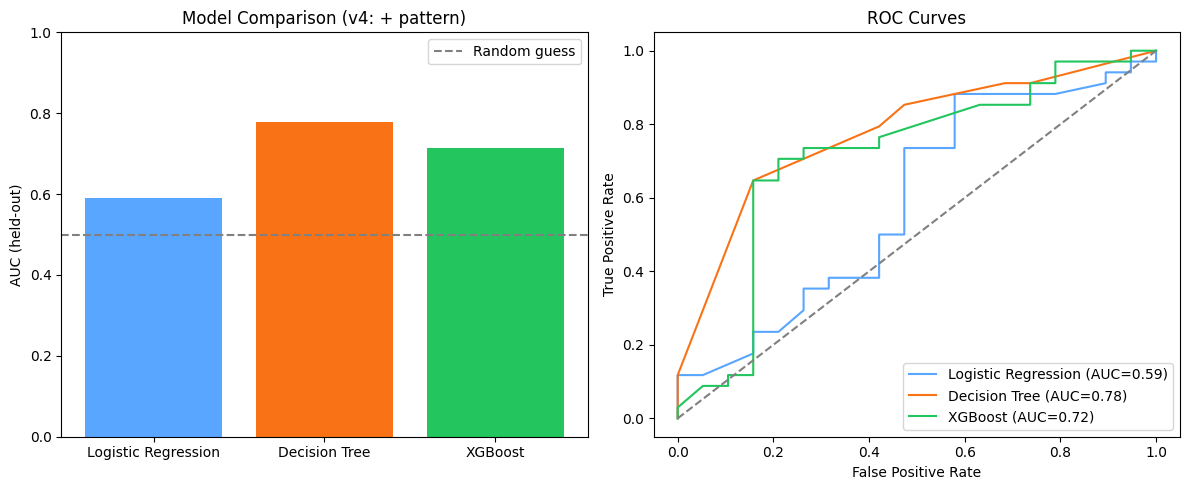

In [9]:
results = pd.DataFrame({
    'model': ['Logistic Regression', 'Decision Tree', 'XGBoost'],
    'auc':   [log_reg_auc, tree_auc, xgb_auc],
})
print(results.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(results['model'], results['auc'], color=['#58a6ff', '#f97316', '#22c55e'])
axes[0].axhline(0.5, color='gray', linestyle='--', label='Random guess')
axes[0].set_ylim(0, 1)
axes[0].set_ylabel('AUC (held-out)')
axes[0].set_title('Model Comparison (v4: + pattern)')
axes[0].legend()

for name, proba, color in [
    ('Logistic Regression', log_reg_proba, '#58a6ff'),
    ('Decision Tree', tree_proba, '#f97316'),
    ('XGBoost', xgb_proba, '#22c55e'),
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[1].plot(fpr, tpr, label=f'{name} (AUC={roc_auc_score(y_test, proba):.2f})', color=color)
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves')
axes[1].legend()

plt.tight_layout()
plt.show()

## 8. Takeaways — why XGBoost shipped despite losing this split's AUC

| model | AUC |
|---|---|
| Logistic Regression | 0.591 |
| Decision Tree | **0.779** |
| XGBoost | 0.715 |

On this run, the single Decision Tree scored highest — yet `picker.py` uses XGBoost. Reasons,
based on the evidence in the cells above rather than the AUC number alone:

- **The test set is tiny and this is one split, not cross-validated.** Only 53 held-out rows from
  a single 80/20 time-based split. A 0.06 AUC gap on n=53 isn't a reliable signal that one model
  will keep winning — it could just as easily flip on the next batch of attempts.
- **The tree's `feature_importances_` (Section 5) look like overfitting to this particular time
  ordering, not a generalizable rule.** ~68% of its importance sits on the two `difficulty_*`
  dummies alone; `prior_failure_rate`, `prior_attempt_count`, and 19 of the 21 `pattern_*` columns
  get exactly zero. A `max_depth=4` tree with that few effective splits is a classic high-variance
  fit — it latched onto a handful of thresholds that happened to separate this train/test boundary.
- **XGBoost's importances (Section 6) are spread far more evenly** across both the history features
  and most pattern categories. That's the effect row/column subsampling + shallow (depth-3) trees
  across 100 estimators is meant to produce — lower variance than any single tree, even if it costs
  some fit on this one split.
- **Logistic Regression is clearly the weakest of the three (AUC 0.591)** — not competitive enough
  to ship, despite being the simplest and most interpretable option.

Net: this was a small-data judgment call in favor of the more variance-robust model, not a clean
AUC win for XGBoost. Revisit once there's meaningfully more attempt history — rerun with proper
cross-validation (not a single time split) before trusting any AUC ranking here, tree included.
